In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Exploratory Data Analysis (EDA)

In [2]:
pharma = pd.read_csv("C:/Users/shanm/Python_Practice/Datasets/Pharma_Industry.csv")
pharma.head(3)

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0


In [3]:
pharma.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [4]:
pharma.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [5]:
pharma.shape

(500, 6)

In [6]:
# Lets check whether data is balanced

pharma['Drug Response'].value_counts()

Drug Response
1    260
0    240
Name: count, dtype: int64

In [7]:
# Lets rename the columns without measurements

user_cols  = ['Drug Dosage', 'Systolic Blood Pressure','Heart Rate', 'Liver Toxicity Index','Blood Glucose Level', 'Drug Response']
pharma.columns = user_cols
pharma.columns

Index(['Drug Dosage', 'Systolic Blood Pressure', 'Heart Rate',
       'Liver Toxicity Index', 'Blood Glucose Level', 'Drug Response'],
      dtype='object')

In [8]:
# Lets check for missing values

pharma.isna().sum()

Drug Dosage                0
Systolic Blood Pressure    0
Heart Rate                 0
Liver Toxicity Index       0
Blood Glucose Level        0
Drug Response              0
dtype: int64

In [9]:
# Lets check for duplicates

pharma.duplicated().sum()

0

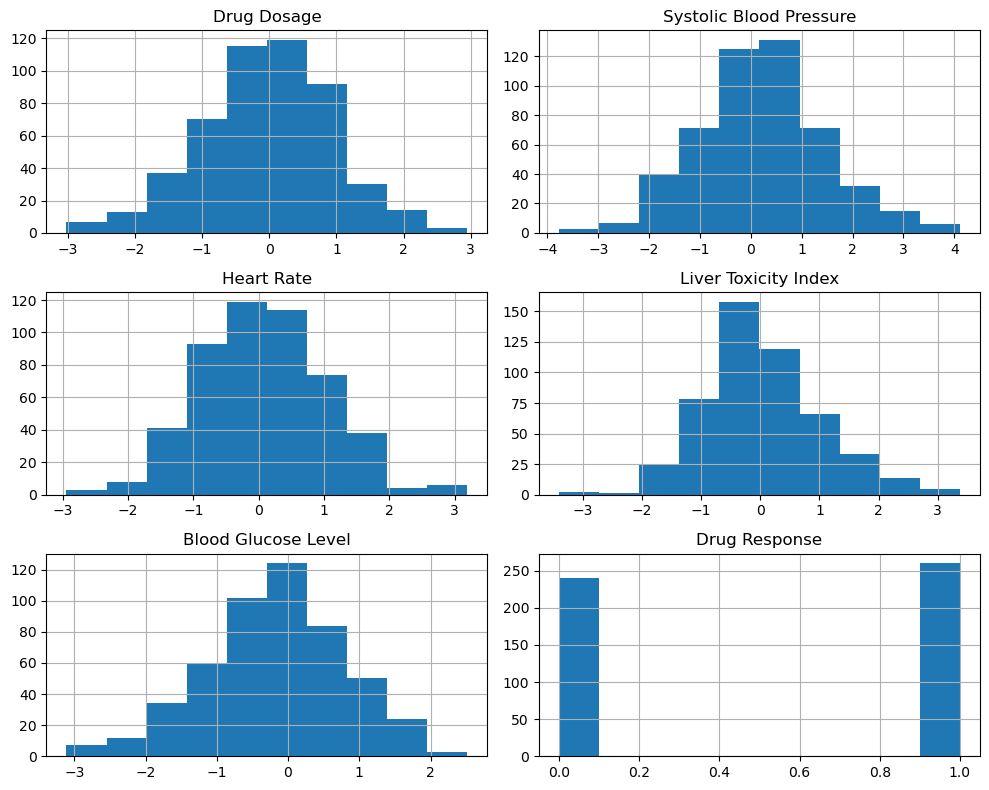

In [10]:
# Lets plot histogram for all the feature

pharma.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

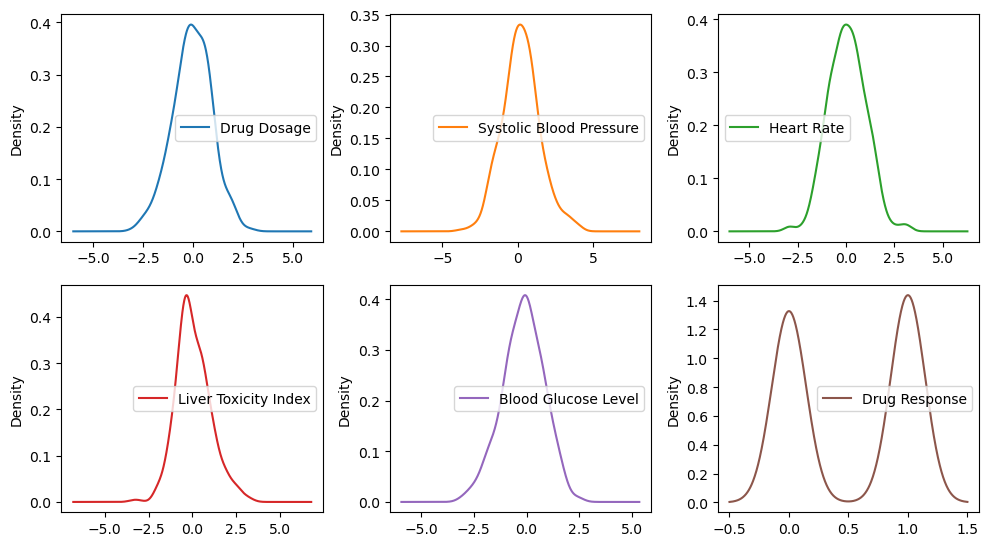

In [11]:
# Lets plot density plot (KDE plot)

pharma.plot(kind='density', subplots=True, layout=(3,3), figsize=(10,8), sharex=False)
plt.tight_layout()
plt.show()

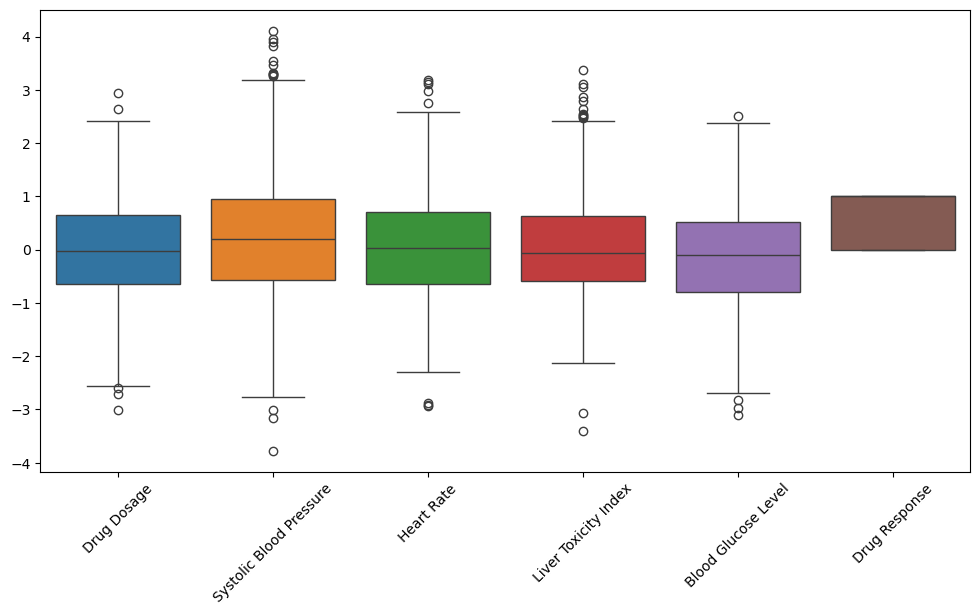

In [12]:
# Box Plot

import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=pharma)
plt.xticks(rotation=45)
plt.show()

Outliers should be paid attention . Since this is medical data, we should not remove outliers without analysing it as it may be serious alarming signal.They may represent real patient responses
They could indicate:
Adverse drug reactions,
High toxicity cases,
Important edge cases. 

- we should analyse, "Is it biologically possible?"

In [13]:
Q1 = pharma.quantile(0.25)
Q3 = pharma.quantile(0.75)
IQR = Q3 - Q1

outliers = ((pharma < (Q1 - 1.5 * IQR)) | (pharma > (Q3 + 1.5 * IQR)))
outliers.sum()

Drug Dosage                 5
Systolic Blood Pressure    14
Heart Rate                  8
Liver Toxicity Index       13
Blood Glucose Level         4
Drug Response               0
dtype: int64

In [14]:
feature_corr = pharma.corr()

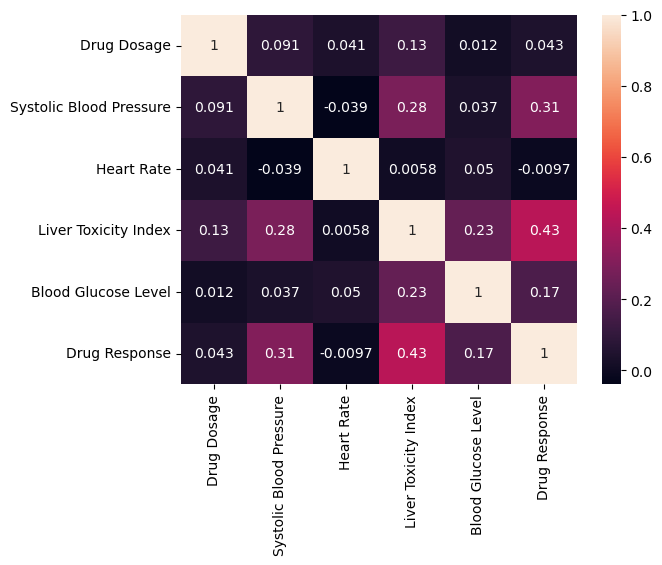

In [15]:
sns.heatmap(feature_corr , annot=True )
plt.show()

Observation:

- Mostly, co-relations are weak.This means your features are largely independent, which is generally good for modeling (low multicollinearity).
- Liver Toxicity Index and Systolic Blood Pressure is moderately co-related with Drug response
- There is weak relationship between Drug Response and Blood Glucose Level , Drug Dosage , Heart rate
- Liver Toxicity Index is moderately co-related with Systolic Blood Pressure and Blood Glucose Level.
- Liver Toxicity Index is the strongest predictor.Higher toxicity means higher likelihood of drug response (or effect)
- Systolic Blood Pressure also matters
- No serious multicollinearity issue.Features still provide unique information
- Heart Rate is Nearly zero correlation with everything.Likely not a useful predictor. Even if we drop that feature, it wont affect results much

# Task 2: Data Preprocessing

There is no features here that to be encoded.Even drug response is already encoded.

In [16]:
# Splitting the data

X = pharma.iloc[:,:-1]
X.head(1)

,Drug Dosage,Systolic Blood Pressure,Heart Rate,Liver Toxicity Index,Blood Glucose Level
0,-0.128538,0.30328,-1.881849,0.258286,-0.792011


In [17]:
y = pharma.iloc[:,-1]
y.head(1)

0    1
Name: Drug Response, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y, test_size=0.2 , random_state=42)
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((400, 5), (100, 5), (400,), (100,))

# Task 3: Data Visualization

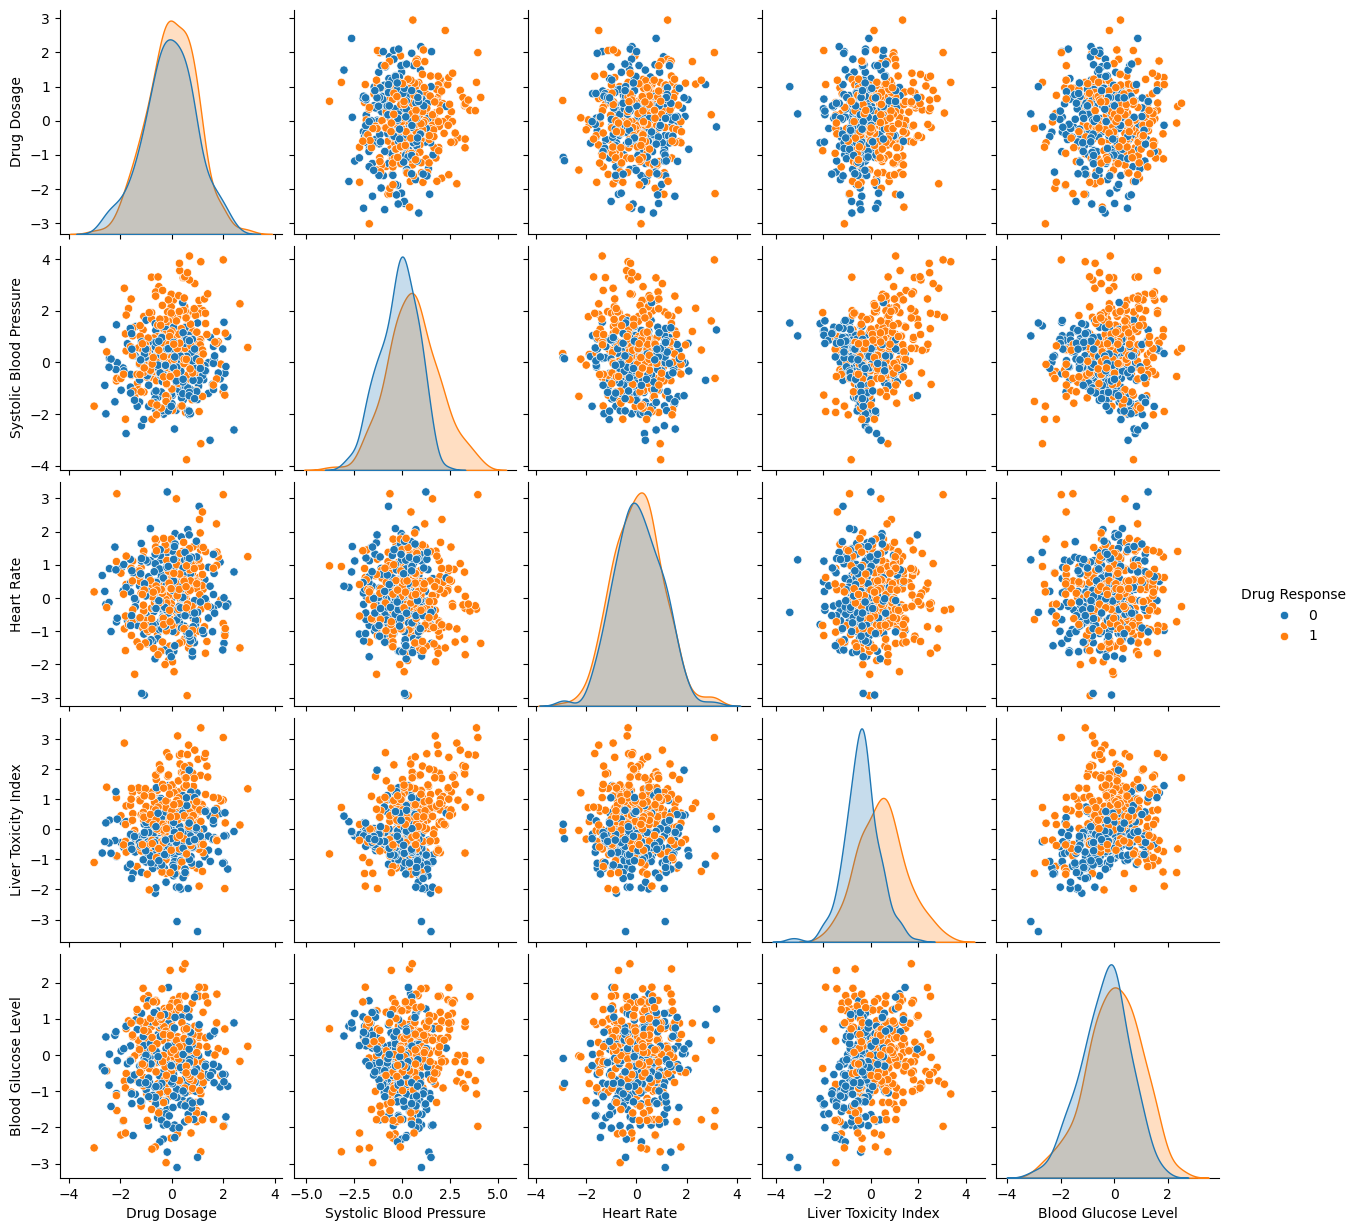

In [19]:
sns.pairplot(pharma , hue="Drug Response")
plt.show()

Observations:

- Features are very much independant of each other and shows a non linear relationship between them
- The pair plot shows that Liver Toxicity Index and Systolic Blood Pressure exhibit some separation between the two drug response classes.
- Most other features show overlapping distributions, indicating weaker predictive power.

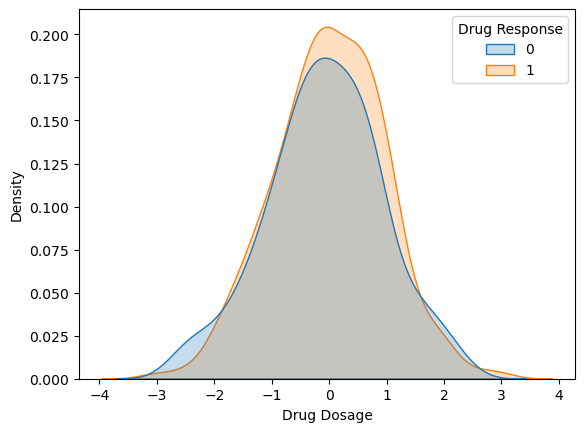

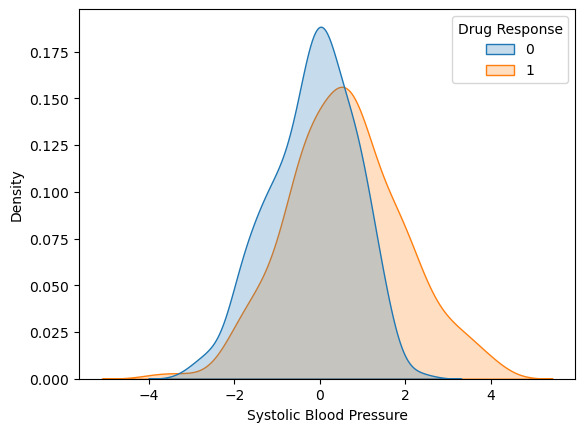

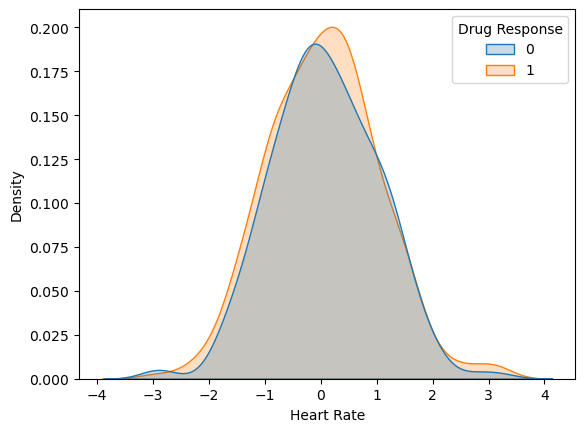

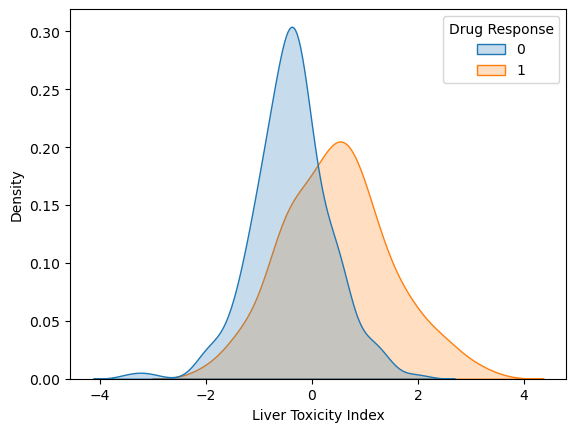

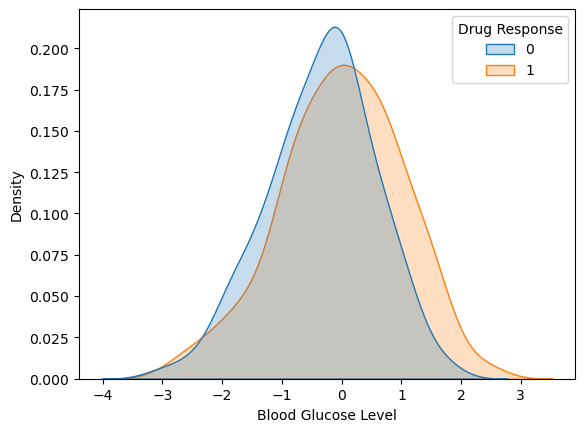

In [20]:
for col in pharma.columns[:-1]:
    sns.kdeplot(data=pharma, x=col, hue="Drug Response", fill=True)
    plt.show()

Observation : 

- Kde plots suggest that features are approximately normally distributed.

Lets check Class distribution via Countplot to check whether is data is balanced or not

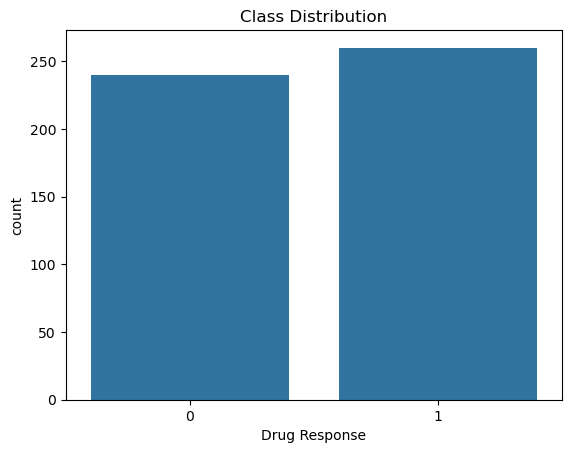

In [21]:
sns.countplot(x="Drug Response", data=pharma)
plt.title("Class Distribution")
plt.show()

Observation :

- The class distribution plot indicates that the dataset is balanced, as both classes (0 and 1) have nearly equal representation. This reduces the risk of model bias toward a particular class

# Task 4: SVM Implementation

In [22]:
from sklearn.svm import SVC

In [23]:
model = SVC(C=1.0 , gamma=0.1, kernel='rbf')

In [24]:
model.fit(X_train , y_train)

SVC(gamma=0.1)

In [25]:
yhat_train = model.predict(X_train)

In [26]:
# Lets evaluate model performace on testing data

In [27]:
from sklearn.metrics import confusion_matrix, classification_report , roc_curve ,roc_auc_score

In [28]:
def plot_auc_roc(y,yhat):
    fpr , tpr , thresh = roc_curve(y,yhat)
    auc = roc_auc_score(y,yhat)
    print(f'AUC: {auc}')
    plt.figure(figsize=(3,3))

    plt.title('AUC - ROC Curve', fontsize=15)
    plt.xlabel('False Positive Rate(FPR)')
    plt.ylabel('True Positive Rate(TPR)')

    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1] , "o--")
    plt.show()
    

In [29]:
def eval_clf_model(y,yhat):
    cm = confusion_matrix(y,yhat)
    plt.figure(figsize=(3,3))
    sns.heatmap(cm ,annot=True , cmap="BuPu" ,cbar=False, fmt='d')
    print(classification_report(y,yhat))

Evaluation on testing data

In [30]:
yhat_test = model.predict(X_test)

AUC: 0.8336038961038961


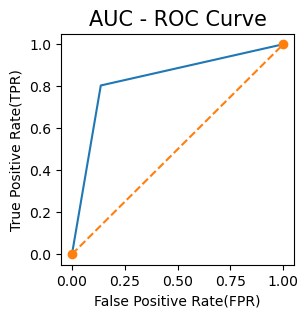

In [31]:
plot_auc_roc(y_test,yhat_test)

              precision    recall  f1-score   support

           0       0.78      0.86      0.82        44
           1       0.88      0.80      0.84        56

    accuracy                           0.83       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.84      0.83      0.83       100



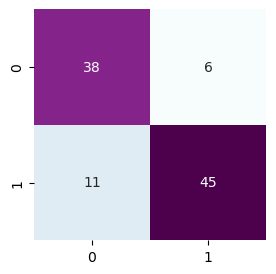

In [32]:
eval_clf_model(y_test,yhat_test)

Accuracy , Precision , Recall and f1_score are above 80% meaning our model is stable and good!

# Task 5: Visualization of SVM Results

Since our model has 5 features , we can't directly visualize all the features.So lets decompose it into 2 features and visualize

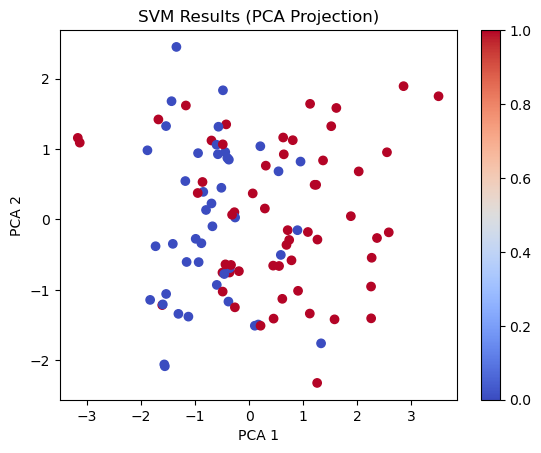

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm')
plt.colorbar()
plt.title("SVM Results (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [34]:
print(np.unique(y_test))


[0 1]


# Task 6: Parameter Tuning and Optimization

In [35]:
from sklearn.svm import SVC

kernels = ['linear', 'rbf', 'poly', 'sigmoid']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"Kernel: {k}, Accuracy: {acc}")


Kernel: linear, Accuracy: 0.78
Kernel: rbf, Accuracy: 0.82
Kernel: poly, Accuracy: 0.69
Kernel: sigmoid, Accuracy: 0.76


rbf kernel has higher accuracy as it is known for handling complex non-linear relationships

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score: 0.7375


In [37]:
best_model = grid.best_estimator_
test_accuracy = best_model.score(X_test, y_test)

print("Optimized Test Accuracy:", test_accuracy)

Optimized Test Accuracy: 0.82


# Task 7: Comparison and Analysis

Support Vector Machines use different kernels to handle linear vs non-linear patterns.

Linear Kernel
- Assumes data is linearly separable
- Fast and simple
- Works well when features are already well-structured

Performance Insight:
- Good accuracy if your dataset is roughly linear
- Lower computational cost
- May underperform if relationships are complex


Polynomial Kernel
- Captures feature interactions (e.g., squared or cubic relationships)
- Adds flexibility compared to linear

Performance Insight:
- Can model moderate non-linearity
- Risk of overfitting if degree is high
- Slower than linear


RBF (Radial Basis Function) Kernel
- Most commonly used
- Handles complex non-linear relationships

Performance Insight:

- Usually highest accuracy for biomedical-like datasets
- Works well when decision boundary is unknown
- Requires tuning of hyperparameters (C, gamma)

Since our model represents non linear relationship between features, its best to use "RBF kernal"

### 2. SVM Strengths & Weaknesses (Based on Dataset)

Pharma_Industry dataset represents a dataset with biomedical features('Drug Dosage', 'Systolic Blood Pressure','Heart Rate', 'Liver Toxicity Index','Blood Glucose Level) and target with binary classification

Strengths
- Works well with small-to-medium datasets
Dataset appears relatively small so  SVM is ideal
- Handles high-dimensional data
Multiple medical features , SVM can find optimal boundaries
- Effective in non-linear classification
- Drug response is non linear.Hence, RBF kernel is powerful here
- Robust to overfitting (with proper tuning)
Especially due to margin maximization

Weaknesses
- Sensitive to feature scaling
Features have different ranges , must use normalization/standardization
- Hard to interpret
Unlike decision trees, SVM does not give clear feature importance
- Computationally expensive
Training becomes slow with large datasets
- Hyperparameter tuning required
Choosing C, gamma, kernel type is critical

Visualization of feature distributions and scatter plots indicated partial overlap between classes, suggesting non-linear decision boundaries. This explains the superior performance of the RBF kernel compared to the linear kernel.

### 3. Practical Implications of SVM in Real-World Classification

In Healthcare (like above dataset)
- Predict drug effectiveness
- Detect disease presence
- Assist in clinical decision-making

Advantages in Real Applications
- High accuracy in complex datasets
- Works well with limited data (common in medical studies)
- Can model non-linear biological relationships


Limitations in Practice
- Not easily interpretable , doctors prefer explainable models
- Requires careful tuning

Real-World Example Statement
In real-world healthcare applications, SVM models can assist in predicting patient response to drugs based on physiological parameters. However, due to limited interpretability, they are often used alongside more explainable models to support clinical decisions.
